In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import os
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
import glob
import warnings
import csv
from collections import OrderedDict
from sklearn.model_selection import train_test_split

In [2]:
import tensorflow as tf
from tensorflow import keras

2026-05-15 20:02:53.898470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778875374.097259      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778875374.158700      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778875374.650930      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778875374.650977      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778875374.650979      57 computation_placer.cc:177] computation placer alr

In [3]:
BASE_INPUT_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
CSV_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "csv")
IMAGE_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "jpeg")
BASE_OUTPUT_PATH = "/kaggle/working/"

In [4]:
IMAGE_SIZE = 256
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
RANDOM_SEED = 42

### Split and Preprocessing

In [5]:
def find_image_in_folder(folder_path):

    if not folder_path or not os.path.isdir(folder_path):
        return None
        
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png')):
                return os.path.join(root, file)
                
    return None

def compute_all_bounding_boxes(mask_path, min_area=100):
    """
    Returns a list of bounding boxes 
    Returns None if mask doesn't exist or is invalid
    """
    if not os.path.exists(mask_path):
        return None

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    _, thresh = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w * h < min_area:
            continue
        boxes.append([x, y, w, h])

    return boxes if boxes else None

def build_metadata_lookup(dicom_info_path, jpeg_base_dir, *args):
    print(f"Building metadata lookup from: {dicom_info_path}")
    master_map = {}
    
    try:
        dicom_info = pd.read_csv(dicom_info_path, dtype=str)
    except FileNotFoundError:
        print(f"Error: Metadata file not found at {dicom_info_path}")
        return master_map

    valid_descriptions = {arg for arg in args}
    filtered_df = dicom_info[dicom_info['SeriesDescription'].isin(valid_descriptions)]

    for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df), desc="Building lookup map"):
        series_desc = row['SeriesDescription'] 
        patient_id_composite = row['PatientID'] 
        
        full_path = None
        
        if 'image_path' in row and pd.notna(row['image_path']):
            rel_path = row['image_path']
            if 'jpeg' in rel_path:
                clean_rel_path = rel_path.split('jpeg')[-1].strip("/\\")
                tmp_path = os.path.join(jpeg_base_dir, clean_rel_path)
            else:
                tmp_path = os.path.join(jpeg_base_dir, rel_path)

            if os.path.exists(tmp_path):
                full_path = tmp_path

        if not full_path:
            series_uid = row['SeriesInstanceUID']
            folder_path = os.path.join(jpeg_base_dir, series_uid)
            full_path = find_image_in_folder(folder_path)
            
        if not full_path or not os.path.exists(full_path): 
            continue

        if patient_id_composite not in master_map:
            master_map[patient_id_composite] = {}
            
        master_map[patient_id_composite][series_desc] = full_path
            
    print(f"Metadata lookup map built. Found {len(master_map)} unique composite keys.")
    return master_map

In [6]:
def BuildMasterDataset(MASTER_LIST_PATH="/kaggle/working/master_dataset.csv", 
                       argument1="cropped images", 
                       argument2="ROI mask images"):
    """
    Build master dataset. If ROI mask is missing:
    - For BENIGN cases: sets mask path to 'n/a' and bbox to 'n/a'
    - For MALIGNANT cases: skips the image entirely
    """
    BASE_INPUT_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
    IMAGE_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "jpeg")
    DICOM_INFO_PATH = os.path.join(BASE_INPUT_PATH, "csv/dicom_info.csv")
    
    INPUT_CSVS = [
        os.path.join(BASE_INPUT_PATH, "csv/mass_case_description_train_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/mass_case_description_test_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/calc_case_description_train_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/calc_case_description_test_set.csv")
    ]

    master_map = build_metadata_lookup(DICOM_INFO_PATH, IMAGE_FOLDER_PATH, argument1, argument2)
    
    if not master_map:
        return

    found_pairs_count = 0
    missing_mask_count = 0
    skipped_malignant_count = 0
    
    with open(MASTER_LIST_PATH, 'w', newline='') as outfile:
        csv_writer = csv.writer(outfile)
        csv_writer.writerow([
            'cropped_image_path', 'roi_mask_path',
            'x_min', 'y_min', 'width', 'height',
            'pathology', 'assessment', 'patient_id', 'series_type', 'mask_status'
        ])

        for filepath in INPUT_CSVS:
            filename = os.path.basename(filepath)
            if not filepath or not os.path.exists(filepath):
                continue
            
            if "mass" in filename.lower():
                type_prefix = "Mass"
            elif "calc" in filename.lower():
                type_prefix = "Calc"
            else:
                continue
                
            if "train" in filename.lower():
                split_prefix = "Training"
            elif "test" in filename.lower():
                split_prefix = "Test"
            else:
                continue
                
            full_prefix = f"{type_prefix}-{split_prefix}"

            with open(filepath, "r") as infile:
                csv_reader = csv.reader(infile)
                header = next(csv_reader)
                
                pathology_idx = header.index('pathology')
                assessment_idx = header.index('assessment')
                patient_id_idx = header.index('patient_id')
                breast_idx = header.index('left or right breast')
                view_idx = header.index('image view')
                abnormality_id_idx = header.index('abnormality id')

                for row in tqdm(csv_reader, desc=f"Processing {filename}"):
                    if not any(row):
                        continue
                    
                    pathology = row[pathology_idx]
                    assessment = row[assessment_idx]
                    patient_id = row[patient_id_idx]
                    side = row[breast_idx]
                    view = row[view_idx]
                    abn_id = row[abnormality_id_idx]
                    
                    try:
                        abn_id_clean = str(int(float(abn_id)))
                    except ValueError:
                        abn_id_clean = str(abn_id).strip()

                    composite_key = f"{full_prefix}_{patient_id}_{side}_{view}_{abn_id_clean}"
                    
                    study_data = master_map.get(composite_key)
                    if not study_data:
                        continue
                    
                    full_crop_path = study_data.get('cropped images')
                    full_mask_path = study_data.get('ROI mask images')
                    
                    if not full_crop_path:
                        continue
                    
                    mask_status = 'valid'
                    
                    if not full_mask_path:
                        pathology_upper = str(pathology).upper()
                        is_benign = 'BENIGN' in pathology_upper and 'MALIGNANT' not in pathology_upper
                        
                        if is_benign:
                            # Set mask path to 'n/a' for benign cases without mask
                            full_mask_path = 'n/a'
                            mask_status = 'n/a'
                            missing_mask_count += 1
                            
                            # Write entry with n/a values
                            csv_writer.writerow([
                                full_crop_path,
                                'n/a',  # roi_mask_path
                                'n/a', 'n/a', 'n/a', 'n/a',  # bbox coordinates
                                pathology,
                                assessment,
                                patient_id,
                                full_prefix,
                                'n/a'  # mask_status
                            ])
                            found_pairs_count += 1
                        else:
                            # Skip malignant cases without masks
                            skipped_malignant_count += 1
                        continue
                    
                    if full_crop_path == full_mask_path and mask_status == 'valid':
                        continue
                    
                    boxes = compute_all_bounding_boxes(full_mask_path, min_area=100)
                    
                    if boxes is None:
                        csv_writer.writerow([
                            full_crop_path,
                            full_mask_path,
                            'n/a', 'n/a', 'n/a', 'n/a',
                            pathology,
                            assessment,
                            patient_id,
                            full_prefix,
                            mask_status
                        ])
                        found_pairs_count += 1
                    else:
                        for (x_min, y_min, width, height) in boxes:
                            csv_writer.writerow([
                                full_crop_path,
                                full_mask_path,
                                x_min, y_min, width, height,
                                pathology,
                                assessment,
                                patient_id,
                                full_prefix,
                                mask_status
                            ])
                            found_pairs_count += 1

    print(f"\n{'='*60}")
    print(f"DATASET BUILD SUMMARY")
    print(f"{'='*60}")
    print(f"Master list saved to: {MASTER_LIST_PATH}")
    print(f"Valid pairs found: {found_pairs_count}")
    print(f"Benign cases without masks (n/a): {missing_mask_count}")
    print(f"Malignant cases skipped (no mask): {skipped_malignant_count}")
    print(f"{'='*60}")

BuildMasterDataset()

Building metadata lookup from: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv


Building lookup map: 100%|██████████| 6814/6814 [00:24<00:00, 274.49it/s]


Metadata lookup map built. Found 3567 unique composite keys.


Processing mass_case_description_train_set.csv: 1318it [00:52, 25.30it/s]
Processing mass_case_description_test_set.csv: 378it [00:15, 24.24it/s]
Processing calc_case_description_train_set.csv: 1546it [01:10, 21.88it/s]
Processing calc_case_description_test_set.csv: 326it [00:00, 770.18it/s]


DATASET BUILD SUMMARY
Master list saved to: /kaggle/working/master_dataset.csv
Valid pairs found: 3445
Benign cases without masks (n/a): 193
Malignant cases skipped (no mask): 127


In [7]:
MASTER_LIST_PATH = "/kaggle/working/master_dataset.csv"

df_master = pd.read_csv(MASTER_LIST_PATH, keep_default_na=False)

unique_patients = df_master["patient_id"].unique()
train_patients, val_patients = train_test_split(
    unique_patients,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_SEED
)

print(f"Splitting {len(unique_patients)} unique patients: {len(train_patients)} for training, {len(val_patients)} for validation.")

Splitting 1510 unique patients: 1208 for training, 302 for validation.


### Data Augmentation

In [8]:
train_df = df_master[df_master['patient_id'].isin(train_patients)].reset_index(drop=True)
val_df = df_master[df_master['patient_id'].isin(val_patients)].reset_index(drop=True)
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GridDistortion(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
   
])

val_transforms = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_57/819158041.py:9: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),


In [9]:
print(f"Total Master CSV : {len(df_master)} lignes")
print(f"Cas valides dans Master : {len(df_master[df_master['mask_status'] == 'valid'])}")
print(f"Cas n/a (sains) dans Master : {len(df_master[df_master['mask_status'] == 'n/a'])}")

print("\n--- Après le Split ---")
print(f"Total Train DF : {len(train_df)} lignes")
print(f"Cas n/a (sains) dans Train : {len(train_df[train_df['mask_status'] == 'n/a'])}")

print(f"Total Val DF : {len(val_df)} lignes")
print(f"Cas n/a (sains) dans Val : {len(val_df[val_df['mask_status'] == 'n/a'])}")

Total Master CSV : 3445 lignes
Cas valides dans Master : 3252
Cas n/a (sains) dans Master : 193

--- Après le Split ---
Total Train DF : 2769 lignes
Cas n/a (sains) dans Train : 154
Total Val DF : 676 lignes
Cas n/a (sains) dans Val : 39


In [10]:
class SegmentationSequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=16, img_size=256, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.img_size = img_size
        self.transforms = transforms

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.batch_size : (idx + 1) * self.batch_size]
        imgs, msks = [], []

        for _, row in batch_df.iterrows():
            image, mask = self._load_data(row)
            imgs.append(image)
            msks.append(mask)

        return np.array(imgs), np.array(msks)

    def _load_data(self, row):
        image = cv2.imread(row["cropped_image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))

        mask_path = row["roi_mask_path"]
        if row["mask_status"] == 'n/a' or mask_path == 'n/a':
            mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        else:
            full_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if full_mask is None:
                mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
            else:
                x_min, y_min = max(0, int(float(row['x_min']))), max(0, int(float(row['y_min'])))
                x_max = min(full_mask.shape[1], x_min + int(float(row['width'])))
                y_max = min(full_mask.shape[0], y_min + int(float(row['height'])))
                mask_crop = full_mask[y_min:y_max, x_min:x_max]
                mask = cv2.resize(mask_crop, (self.img_size, self.img_size))
        
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        mask = mask.astype(np.float32) / 255.0

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=-1)
            
        return image, mask

In [11]:

train_generator = SegmentationSequence(
    dataframe=train_df, 
    batch_size=BATCH_SIZE, 
    img_size=IMAGE_SIZE,
    transforms=train_transforms
)

val_generator = SegmentationSequence(
    dataframe=val_df, 
    batch_size=BATCH_SIZE, 
    img_size=IMAGE_SIZE,
    transforms=val_transforms
)

print(f"Pret ")
print(f"Échantillons : Train={len(train_df)} | Val={len(val_df)}")

Pret 
Échantillons : Train=2769 | Val=676


### Verification

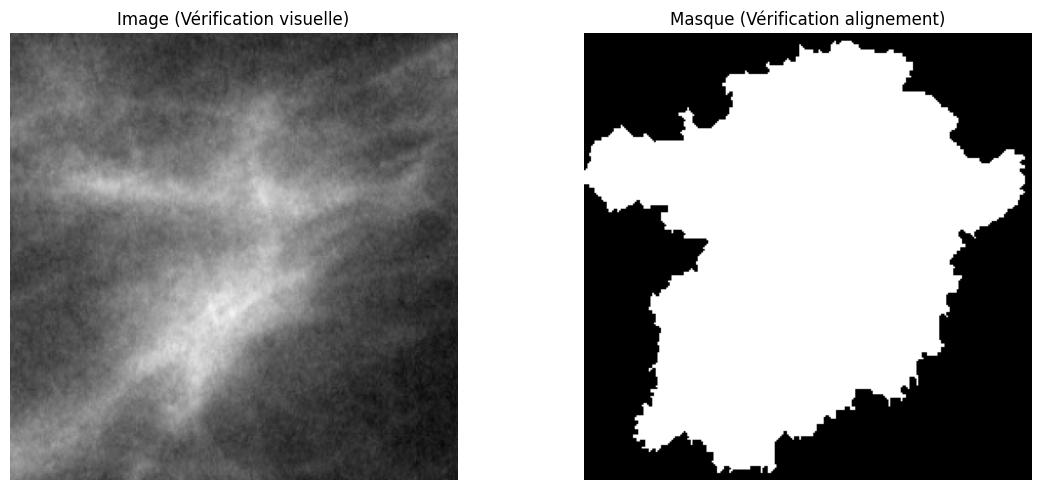

In [12]:
X_batch, y_batch = train_generator[0]

idx = 15
img = X_batch[idx]
mask = y_batch[idx]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = (img * std + mean) 
img_display = np.clip(img_display, 0, 1) 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title("Image (Vérification visuelle)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Masque (Vérification alignement)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Metrics

In [13]:
from tensorflow.keras import backend as K
def dice_coef(y_true,y_pred,smooth=1e-6):
    # we flat out tensor
    y_true_f=K.flatten(K.cast(y_true,'float32'))
    y_pred_f=K.flatten(y_pred)

    #calculate intersection
    intersection=K.sum(y_true_f*y_pred_f)
    return (2.*intersection+smooth) / (K.sum(y_true_f)+K.sum(y_pred_f)+smooth)
def dice_loss(y_true,y_pred):
    return 1-dice_coef(y_true,y_pred)

In [14]:
def specificity(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def f1_score(y_true, y_pred):
    p = keras.metrics.Precision()(y_true, y_pred)
    r = keras.metrics.Recall()(y_true, y_pred)
    return 2 * ((p * r) / (p + r + K.epsilon()))

In [15]:
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = 1.0 - dice_coef(y_true, y_pred)
    return bce + dice_loss

### Architecture

In [16]:
img_size=(256,256)
def unet_model(img_size, num_classes):
    inputs=keras.Input(shape=img_size+(3,))
    x=keras.layers.Rescaling(1./255)(inputs)
    c1=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(x)
    c1=keras.layers.Dropout(0.1)(c1)
    c1=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(c1)
    p1=keras.layers.MaxPooling2D((2,2))(c1)

    c2=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(p1)
    c2=keras.layers.Dropout(0.1)(c2)
    c2=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(c2)
    p2=keras.layers.MaxPooling2D((2,2))(c2)

    c3=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(p2)
    c3=keras.layers.Dropout(0.2)(c3)
    c3=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(c3)
    p3=keras.layers.MaxPooling2D((2,2))(c3)

    c4=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(p3)
    c4=keras.layers.Dropout(0.2)(c4)
    c4=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(c4)
    p4=keras.layers.MaxPooling2D((2,2))(c4)

    c5=keras.layers.Conv2D(256,3,activation="relu", kernel_initializer="he_normal", padding="same")(p4)
    c5=keras.layers.Dropout(0.3)(c5)
    c5=keras.layers.Conv2D(256,3,activation="relu", kernel_initializer="he_normal", padding="same")(c5)

    u6=keras.layers.Conv2DTranspose(128,(2,2),strides=(2,2),padding="same")(c5)
    u6=keras.layers.concatenate([u6,c4])
    c6=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(u6)
    c6=keras.layers.Dropout(0.2)(c6)
    c6=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(c6)

    u7=keras.layers.Conv2DTranspose(64,(2,2),strides=(2,2),padding="same")(c6)
    u7=keras.layers.concatenate([u7,c3])
    c7=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(u7)
    c7=keras.layers.Dropout(0.2)(c7)
    c7=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(c7)

    u8=keras.layers.Conv2DTranspose(32,(2,2),strides=(2,2),padding="same")(c7)
    u8=keras.layers.concatenate([u8,c2])
    c8=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(u8)
    c8=keras.layers.Dropout(0.1)(c8)
    c8=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(c8)

    u9=keras.layers.Conv2DTranspose(16,(2,2),strides=(2,2),padding="same")(c8)
    u9=keras.layers.concatenate([u9,c1])
    c9=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(u9)
    c9=keras.layers.Dropout(0.1)(c9)
    c9=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(c9)

    outputs=keras.layers.Conv2D(1,(1,1),activation="sigmoid")(c9)
    model=keras.Model(inputs,outputs)
    return model

model=unet_model(img_size,1)
model.compile(optimizer="adam", loss=bce_dice_loss, metrics=[
    "accuracy",
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'), 
    specificity, 
    dice_coef])
model.summary()

I0000 00:00:1778876038.327650      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778876038.333591      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0] 

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [17]:
callbacks=[
    keras.callbacks.ModelCheckpoint("DDSM_UNet.keras",
                                    save_best_only=True),
    keras.callbacks.EarlyStopping(
        patience=10, monitor="val_loss"),
    
    keras.callbacks.ReduceLROnPlateau(
        factor=0.2, patience=5, monitor="val_loss")
]
history=model.fit(train_generator,
                  epochs=50,
                  batch_size=64,
                  validation_data=(val_generator),
                  callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1778876053.972436     140 service.cc:152] XLA service 0x79ece4004120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778876053.972493     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778876053.972497     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778876055.401435     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 20:14:19.913924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 20:14:20.057371: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 20:14:22.259281: E external/local_xl

  8/174 ━━━━━━━━━━━━━━━━━━━━ 1:39 597ms/step - accuracy: 0.5738 - dice_coef: 0.5518 - loss: 1.1400 - precision: 0.6278 - recall: 0.6758 - specificity: 0.3586

2026-05-15 20:14:46.194721: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 20:14:46.474285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 20:14:46.820530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 20:14:46.968485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


174/174 ━━━━━━━━━━━━━━━━━━━━ 183s 882ms/step - accuracy: 0.6236 - dice_coef: 0.6085 - loss: 1.0510 - precision: 0.6278 - recall: 0.9317 - specificity: 0.1472 - val_accuracy: 0.6285 - val_dice_coef: 0.6541 - val_loss: 0.9150 - val_precision: 0.6278 - val_recall: 0.9968 - val_specificity: 0.0148 - learning_rate: 0.0010
Epoch 2/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 104s 598ms/step - accuracy: 0.7046 - dice_coef: 0.6875 - loss: 0.8810 - precision: 0.7069 - recall: 0.8685 - specificity: 0.5096 - val_accuracy: 0.7718 - val_dice_coef: 0.7656 - val_loss: 0.7645 - val_precision: 0.7532 - val_recall: 0.9446 - val_specificity: 0.5113 - learning_rate: 0.0010
Epoch 3/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 103s 591ms/step - accuracy: 0.7782 - dice_coef: 0.7408 - loss: 0.7384 - precision: 0.7966 - recall: 0.8616 - specificity: 0.6704 - val_accuracy: 0.7968 - val_dice_coef: 0.7729 - val_loss: 0.6929 - val_precision: 0.7982 - val_recall: 0.9033 - val_specificity: 0.6514 - learning_rate: 0.0010
Epoch 4/50
174/174 ━━

### Visualisation

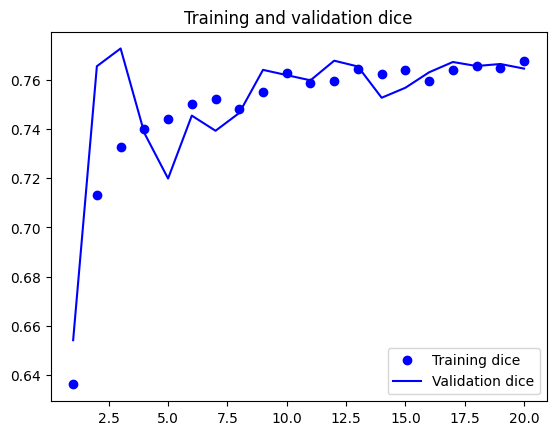

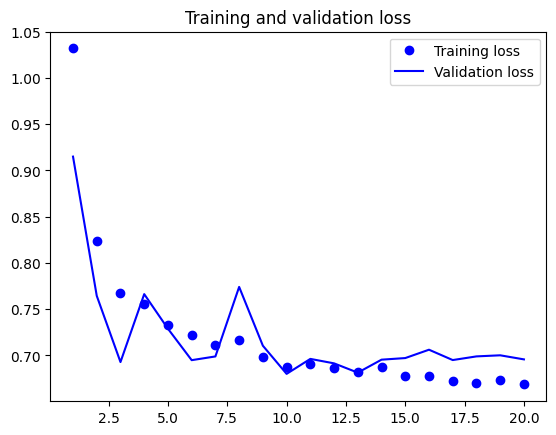

In [18]:

dice = history.history["dice_coef"]
val_dice = history.history["val_dice_coef"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(dice) + 1)
plt.plot(epochs, dice, "bo", label="Training dice")
plt.plot(epochs, val_dice, "b", label="Validation dice")
plt.title("Training and validation dice")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


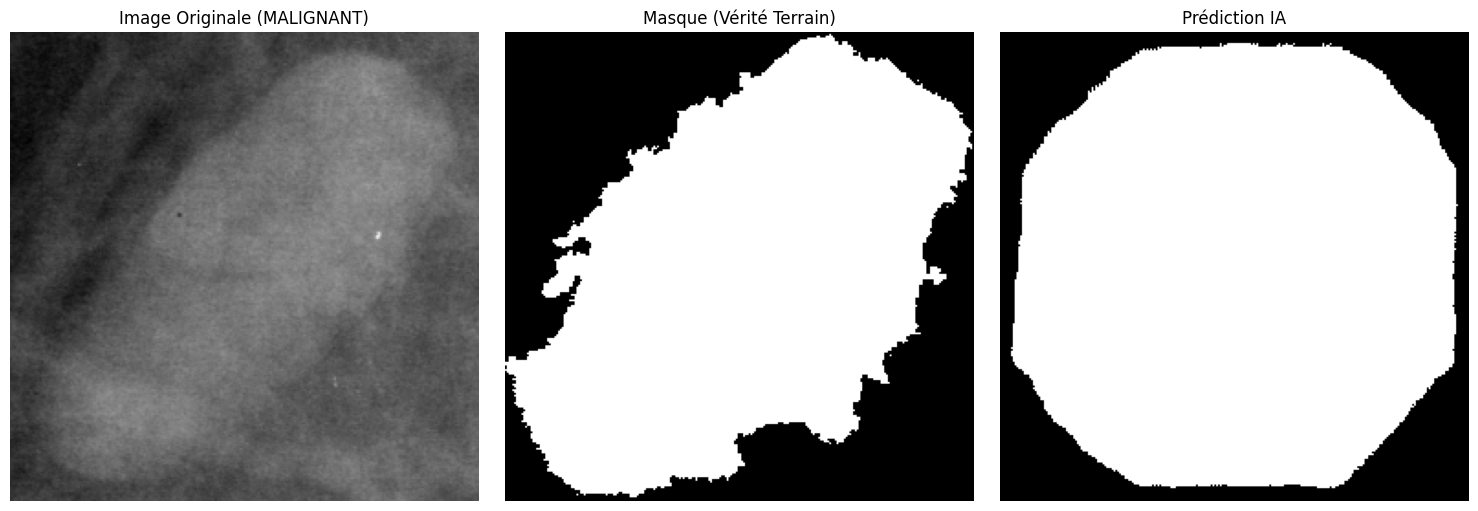

In [27]:
idx = 9
IMAGE_SIZE = 256 

img_path_to_test = val_df['cropped_image_path'].iloc[idx]
msk_path_to_test = val_df['roi_mask_path'].iloc[idx]

raw_img = cv2.imread(img_path_to_test)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (IMAGE_SIZE, IMAGE_SIZE))

raw_msk = cv2.imread(msk_path_to_test, cv2.IMREAD_GRAYSCALE)

x_min, y_min = int(float(val_df['x_min'].iloc[idx])), int(float(val_df['y_min'].iloc[idx]))
w, h = int(float(val_df['width'].iloc[idx])), int(float(val_df['height'].iloc[idx]))
raw_msk = raw_msk[y_min:y_min+h, x_min:x_min+w]

raw_msk_resized = cv2.resize(raw_msk, (IMAGE_SIZE, IMAGE_SIZE))
_, raw_msk_resized = cv2.threshold(raw_msk_resized, 127, 255, cv2.THRESH_BINARY)

transformed = val_transforms(image=raw_img)
img_for_model = transformed["image"]

preds = model.predict(np.expand_dims(img_for_model, 0))

if isinstance(preds, list):
    pred_final = preds[1][0] 
else:
    pred_final = preds[0]

pred_mask = (pred_final > 0.5).astype("uint8")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(raw_img)
plt.title(f"Image Originale ({val_df['pathology'].iloc[idx]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(raw_msk_resized, cmap="gray")
plt.title("Masque (Vérité Terrain)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask.squeeze() * 255, cmap="gray")
plt.title("Prédiction IA")
plt.axis("off")

plt.tight_layout()
plt.show()

### Evaluation

In [28]:
model.evaluate(val_generator)

43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 391ms/step - accuracy: 0.8143 - dice_coef: 0.8151 - loss: 0.5873 - precision: 0.7921 - recall: 0.9587 - specificity: 0.5706


[0.6957540512084961,
 0.7874407172203064,
 0.7695137858390808,
 0.94222491979599,
 0.5591559410095215,
 0.7646607756614685]